In [34]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

import numpy as np

In [3]:
# univariate statistics
max_steps = 100000
step_size = 1000

ts = [x * step_size for x in range(1, int(max_steps/step_size) + 1)]
ts

[1000,
 2000,
 3000,
 4000,
 5000,
 6000,
 7000,
 8000,
 9000,
 10000,
 11000,
 12000,
 13000,
 14000,
 15000,
 16000,
 17000,
 18000,
 19000,
 20000,
 21000,
 22000,
 23000,
 24000,
 25000,
 26000,
 27000,
 28000,
 29000,
 30000,
 31000,
 32000,
 33000,
 34000,
 35000,
 36000,
 37000,
 38000,
 39000,
 40000,
 41000,
 42000,
 43000,
 44000,
 45000,
 46000,
 47000,
 48000,
 49000,
 50000,
 51000,
 52000,
 53000,
 54000,
 55000,
 56000,
 57000,
 58000,
 59000,
 60000,
 61000,
 62000,
 63000,
 64000,
 65000,
 66000,
 67000,
 68000,
 69000,
 70000,
 71000,
 72000,
 73000,
 74000,
 75000,
 76000,
 77000,
 78000,
 79000,
 80000,
 81000,
 82000,
 83000,
 84000,
 85000,
 86000,
 87000,
 88000,
 89000,
 90000,
 91000,
 92000,
 93000,
 94000,
 95000,
 96000,
 97000,
 98000,
 99000,
 100000]

In [4]:
df = pd.read_csv("./NC_Markov_stats_100000/chain_outputs_0_1000.csv")

for t in ts[1:]:
    df2 = pd.read_csv(f"./NC_Markov_stats_100000/chain_outputs_0_{t}.csv")
    df = pd.concat([df, df2], ignore_index=True)

In [ ]:
df

,Unnamed: 0,County splits,MM,EG,PB,DWins,PP
0,0,11,-0.057581,-0.256115,-0.285714,3,4.170030
1,1,11,-0.054311,-0.181862,-0.214286,4,4.213400
2,2,12,-0.059772,-0.181862,-0.142857,4,4.491564
3,3,12,-0.059772,-0.181862,-0.142857,4,4.491564
4,4,12,-0.059772,-0.181862,-0.142857,4,4.491564
...,...,...,...,...,...,...,...
99994,995,11,-0.032863,-0.039581,-0.071429,6,4.073051
99995,996,11,-0.032844,-0.039463,-0.071429,6,4.081661
99996,997,12,-0.032347,-0.039463,-0.071429,6,4.118838
99997,998,12,-0.032347,-0.039463,-0.071429,6,4.118838


In [ ]:
con_stats = pd.read_csv("./NC_Stats/NC_Compactness_CON_RDH.csv")
sum([1/x for x in con_stats['PP']])/14

con_stats2=pd.read_csv("./NC_Stats/")

4.17002956008203

In [47]:
counts = Counter(df['County splits'])

categories = list(counts.keys())
frequencies = list(counts.values())
plt.bar(categories, frequencies)
plt.axvline(11, color='red',label='Enacted')
plt.title("County splits")
plt.savefig('./NC_Markov_stats_100000/graphs/cs.png')
plt.close()

plt.hist(df['MM'],bins=100)
plt.axvline(-0.05668032542711077, color='red',label='Enacted')
plt.title("Mean median")
plt.savefig('./NC_Markov_stats_100000/graphs/mm.png')
plt.close()

plt.hist(df['EG'],bins=100)
plt.axvline(-0.25611450640053, color='red',label='Enacted')
plt.title("Efficiency gap")
plt.savefig('./NC_Markov_stats_100000/graphs/eg.png')
plt.close()

plt.hist(df['PB'])
plt.axvline(-0.2857142857142857, color='red',label='Enacted')
plt.title("Partisan bias")
plt.savefig('./NC_Markov_stats_100000/graphs/pb.png')
plt.close()

plt.hist(df['PP'],bins=100)
plt.axvline(4.17002956008203, color='red',label='Enacted')
plt.title("Polsby popper")
plt.savefig('./NC_Markov_stats_100000/graphs/pp.png')
plt.close()

counts2 = Counter(df['DWins'])

categories = list(counts2.keys())
frequencies = list(counts2.values())

plt.bar(categories, frequencies)
plt.axvline(3, color='red',label='Enacted')
plt.title("Dem wins")
plt.savefig('./NC_Markov_stats_100000/graphs/dwins.png')
plt.close()

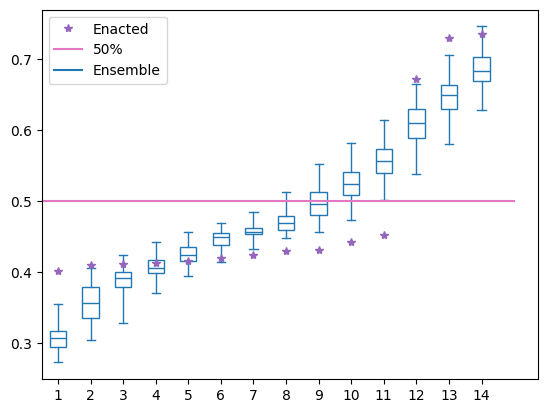

In [44]:
a = []

for t in ts:
    tempvotes=np.loadtxt(f"./NC_Markov_stats_100000/DemPercs_0_{t}.csv", delimiter=",")
    for s in range(step_size-1):
        a.append(tempvotes[s,:])

a = np.array(a)

medianprops = dict(color='black')

fig1= plt.figure()
ax1 = fig1.add_subplot(111)

c="tab:blue"

plt.boxplot(
    a,
    whis=[1,99],
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor="None", color=c),
    capprops=dict(color=c),
    whiskerprops=dict(color=c),
    flierprops=dict(color=c,markeredgecolor=c),
    medianprops=dict(color=c)
)

plt.plot(range(1,15),sorted([0.41886754221788536,0.4102550692587003,0.4015134041175902,0.4518196604772827,0.44262948889535925,0.42972030525431776,0.42424257414722344,0.41316756365141794,0.4152301363495878,0.4105112876315188,0.7289525437627258,0.4301783057905161,0.7353109186481949,0.6714747293927874]),"*",color="tab:purple",label="Enacted")

plt.plot([0.5,15],[0.5,0.5],color="tab:pink",label="50%")
plt.plot([],[],color='tab:blue',label='Ensemble')
plt.legend()

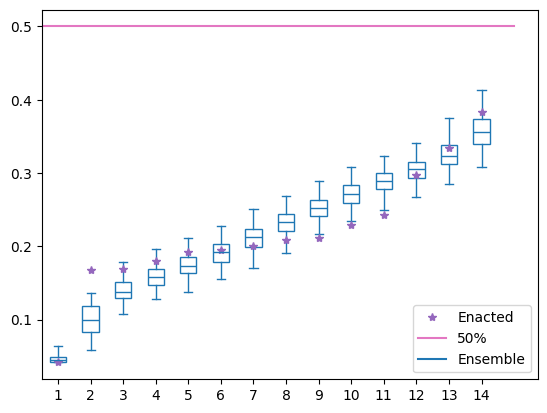

In [48]:
a = []

for t in ts:
    tempvotes=np.loadtxt(f"./NC_Markov_stats_100000/BlackPercs_0_{t}.csv", delimiter=",")
    for s in range(step_size-1):
        a.append(tempvotes[s,:])

a = np.array(a)

medianprops = dict(color='black')

fig1= plt.figure()
ax1 = fig1.add_subplot(111)

c="tab:blue"

plt.boxplot(
    a,
    whis=[1,99],
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor="None", color=c),
    capprops=dict(color=c),
    whiskerprops=dict(color=c),
    flierprops=dict(color=c,markeredgecolor=c),
    medianprops=dict(color=c)
)

plt.plot(range(1,15),sorted([0.22942044041576282,
 0.19229480241029692,
 0.17956793200417584,
 0.04239387124357679,
 0.3343947666604468,
 0.2090103932041959,
 0.16776705580854165,
 0.20011859792092224,
 0.19469551364130155,
 0.1695334362636302,
 0.2111577988153698,
 0.29668742389424085,
 0.38389802664664036,
 0.24333683400032827]),"*",color="tab:purple",label="Enacted")

plt.plot([0.5,15],[0.5,0.5],color="tab:pink",label="50%")
plt.plot([],[],color='tab:blue',label='Ensemble')
plt.legend()

In [45]:
con_stats

,CON,% Black,PP,CH,R,LW,P
0,0,0.433513,0.320790,0.804027,0.423419,0.628601,12.025308
1,1,0.032553,0.281191,0.689318,0.258364,0.618919,4.714454
2,2,0.003562,0.262383,0.849532,0.263570,0.502872,8.823520
3,3,0.046660,0.276655,0.809728,0.572504,0.878653,1.791469
4,4,0.195721,0.137291,0.563963,0.378663,0.885410,9.430845
5,5,0.060238,0.160266,0.573011,0.292633,0.639320,6.695474
6,6,0.107506,0.341916,0.781199,0.377838,0.642192,2.034989
7,7,0.069509,0.268208,0.758306,0.570520,0.920757,7.915087
8,8,0.101835,0.287610,0.769896,0.493865,0.954342,3.507701
9,9,0.018843,0.220736,0.692524,0.239253,0.345601,7.908445
